This script is a modification of Model 9 V1 into a modular specialist pipeline.

- Model 3 V3 is kept as the overhead RGB carbohydrate specialist.
- A new side-angle DINOv3 model is trained only on total mass and to predict this.
- A final combiner model is trained on the predictions from those two specialists in order to output a single carbohydrate estimate.

The overall goal remains carbohydrate estimation, but the mass branch is now fully separated from the carbohydrate branch and is only responsible for mass estimation from side-angle images.


START WITH CPU FOR DATA LOADING

Settings

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np


Parameters

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_split_metadata.csv")

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

print("DATASET_DIR:", DATASET_DIR)
print("DATASET_DIR exists:", DATASET_DIR.exists())
print("METADATA_CSV exists:", METADATA_CSV.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)
print("PREP_DIR:", PREP_DIR)

DATASET_DIR: /content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3
DATASET_DIR exists: True
METADATA_CSV exists: True
OUTPUT_DIR: /content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner
PREP_DIR: /content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/prep_files


Loading metadata and dataset

In [ ]:
df_meta = pd.read_csv(METADATA_CSV)

print("Metadata shape:", df_meta.shape)
print(df_meta["split"].value_counts(dropna=False))
display(df_meta.head())

Metadata shape: (3262, 5)
split
train    2421
test      507
val       334
Name: count, dtype: int64


,dish_id,total_mass,total_carb,split,source_cafe
0,dish_1556575327,152.0,10.618,test,cafe1
1,dish_1557861216,1.0,0.000,test,cafe1
2,dish_1557862345,63.0,0.000,test,cafe1
3,dish_1557862696,77.0,3.850,test,cafe1
4,dish_1557862738,118.0,0.000,test,cafe1


In [ ]:
def find_frame_in_camera_dir(camera_dir: Path, frame_prefix: str):
    if not camera_dir.exists() or not camera_dir.is_dir():
        return None

    preferred_names = [
        f"{frame_prefix}.jpg",
        f"{frame_prefix}.jpeg",
        f"{frame_prefix}.png",
        f"{frame_prefix}.JPG",
        f"{frame_prefix}.JPEG",
        f"{frame_prefix}.PNG",
    ]

    for fname in preferred_names:
        p = camera_dir / fname
        if p.exists():
            return str(p)

    matches = []
    for p in sorted(camera_dir.iterdir()):
        if p.is_file() and p.stem.lower().startswith(frame_prefix.lower()):
            matches.append(p)

    if len(matches) == 0:
        return None

    return str(matches[0])

In [ ]:
def build_multiview_paths_model7_style(dish_id):
    dish_id = str(dish_id)
    dish_dir = DATASET_DIR / dish_id
    side_root = dish_dir / "side_angles"

    record = {
        "dish_id": dish_id,
        "rgb_path": str(dish_dir / "overhead" / "rgb.png"),
    }

    camera_map = {
        "camera_A": "a",
        "camera_B": "b",
        "camera_C": "c",
        "camera_D": "d",
    }

    for cam_name, cam_short in camera_map.items():
        cam_dir = side_root / cam_name
        record[f"side_{cam_short}_start_path"] = find_frame_in_camera_dir(cam_dir, "frame_start")
        record[f"side_{cam_short}_mid_path"]   = find_frame_in_camera_dir(cam_dir, "frame_mid")

    return record

In [ ]:
sample_dish_id = str(df_meta.iloc[0]["dish_id"])
sample_paths = build_multiview_paths_model7_style(sample_dish_id)

print("Sample dish:", sample_dish_id)
for k, v in sample_paths.items():
    print(k, "->", v)

Sample dish: dish_1556575327
dish_id -> dish_1556575327
rgb_path -> /content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3/dish_1556575327/overhead/rgb.png
side_a_start_path -> /content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3/dish_1556575327/side_angles/camera_A/frame_start.jpg
side_a_mid_path -> /content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3/dish_1556575327/side_angles/camera_A/frame_mid.jpg
side_b_start_path -> /content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3/dish_1556575327/side_angles/camera_B/frame_start.jpg
side_b_mid_path -> /content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3/dish_1556575327/side_angles/camera_B/frame_mid.jpg
side_c_start_path -> /content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3/dish_1556575327/side_angles/camera_C/frame_start.jpg
side_c_mid_path -> /content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3/dish_1556575327/side_angles/camera_C/frame_mid.jpg
side_d_start_path -> /content/dri

In [ ]:
records = []

for dish_id in df_meta["dish_id"].astype(str).tolist():
    records.append(build_multiview_paths_model7_style(dish_id))

paths_df = pd.DataFrame(records)

df = df_meta.copy()
df["dish_id"] = df["dish_id"].astype(str)
paths_df["dish_id"] = paths_df["dish_id"].astype(str)

df = df.merge(paths_df, on="dish_id", how="left")

display(df.head())
print("Shape after merge:", df.shape)

,dish_id,total_mass,total_carb,split,source_cafe,rgb_path,side_a_start_path,side_a_mid_path,side_b_start_path,side_b_mid_path,side_c_start_path,side_c_mid_path,side_d_start_path,side_d_mid_path
0,dish_1556575327,152.0,10.618,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...
1,dish_1557861216,1.0,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...
2,dish_1557862345,63.0,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...
3,dish_1557862696,77.0,3.850,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...
4,dish_1557862738,118.0,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...


Shape after merge: (3262, 14)


In [ ]:
side_path_columns = [
    "side_a_start_path",
    "side_a_mid_path",
    "side_b_start_path",
    "side_b_mid_path",
    "side_c_start_path",
    "side_c_mid_path",
    "side_d_start_path",
    "side_d_mid_path",
]

In [ ]:
def safe_exists(path_str):
    if pd.isna(path_str):
        return False
    try:
        return Path(path_str).exists()
    except Exception:
        return False

In [ ]:
from tqdm.auto import tqdm
tqdm.pandas()

df["rgb_exists"] = df["rgb_path"].progress_apply(safe_exists)

for col in side_path_columns:
    df[f"{col}_exists"] = df[col].progress_apply(safe_exists)

display(df.head())

  0%|          | 0/3262 [00:00<?, ?it/s]

  0%|          | 0/3262 [00:00<?, ?it/s]

  0%|          | 0/3262 [00:00<?, ?it/s]

  0%|          | 0/3262 [00:00<?, ?it/s]

  0%|          | 0/3262 [00:00<?, ?it/s]

  0%|          | 0/3262 [00:00<?, ?it/s]

  0%|          | 0/3262 [00:00<?, ?it/s]

  0%|          | 0/3262 [00:00<?, ?it/s]

  0%|          | 0/3262 [00:00<?, ?it/s]

,dish_id,total_mass,total_carb,split,source_cafe,rgb_path,side_a_start_path,side_a_mid_path,side_b_start_path,side_b_mid_path,...,side_d_mid_path,rgb_exists,side_a_start_path_exists,side_a_mid_path_exists,side_b_start_path_exists,side_b_mid_path_exists,side_c_start_path_exists,side_c_mid_path_exists,side_d_start_path_exists,side_d_mid_path_exists
0,dish_1556575327,152.0,10.618,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,True,True,True,True,True,True,True
1,dish_1557861216,1.0,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,True,True,True,True,True,True,True
2,dish_1557862345,63.0,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,True,True,True,True,True,True,True
3,dish_1557862696,77.0,3.850,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,True,True,True,True,True,True,True
4,dish_1557862738,118.0,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,True,True,True,True,True,True,True


Summary of dishes with missing side angle images

In [ ]:
summary_rows = []

summary_rows.append({
    "column": "rgb_path",
    "exists_count": int(df["rgb_exists"].sum()),
    "missing_count": int((~df["rgb_exists"]).sum())
})

for col in side_path_columns:
    exists_col = f"{col}_exists"
    summary_rows.append({
        "column": col,
        "exists_count": int(df[exists_col].sum()),
        "missing_count": int((~df[exists_col]).sum())
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,column,exists_count,missing_count
0,rgb_path,3262,0
1,side_a_start_path,2686,576
2,side_a_mid_path,2686,576
3,side_b_start_path,3082,180
4,side_b_mid_path,3082,180
5,side_c_start_path,2940,322
6,side_c_mid_path,2940,322
7,side_d_start_path,3094,168
8,side_d_mid_path,3094,168


Filtering so the dataset only contains complete dishes (meaning overhead and all side angle images)

In [ ]:
valid_mask = df["rgb_exists"].copy()

for col in side_path_columns:
    valid_mask &= df[f"{col}_exists"]

df_filtered = df[valid_mask].copy().reset_index(drop=True)

print("Original rows:", len(df))
print("Filtered rows:", len(df_filtered))
print(df_filtered["split"].value_counts(dropna=False))

Original rows: 3262
Filtered rows: 2629
split
train    1904
test      401
val       324
Name: count, dtype: int64


In [ ]:
columns_to_keep = [
    "dish_id",
    "total_carb",
    "total_mass",
    "split",
    "source_cafe",
    "rgb_path",
    "side_a_start_path",
    "side_a_mid_path",
    "side_b_start_path",
    "side_b_mid_path",
    "side_c_start_path",
    "side_c_mid_path",
    "side_d_start_path",
    "side_d_mid_path",
]

df_filtered = df_filtered[columns_to_keep].copy()
display(df_filtered.head())

,dish_id,total_carb,total_mass,split,source_cafe,rgb_path,side_a_start_path,side_a_mid_path,side_b_start_path,side_b_mid_path,side_c_start_path,side_c_mid_path,side_d_start_path,side_d_mid_path
0,dish_1556575327,10.618,152.0,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...
1,dish_1557861216,0.000,1.0,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...
2,dish_1557862345,0.000,63.0,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...
3,dish_1557862696,3.850,77.0,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...
4,dish_1557862738,0.000,118.0,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...


Splitting the dataset

In [ ]:
train_df = df_filtered[df_filtered["split"] == "train"].copy().reset_index(drop=True)
val_df   = df_filtered[df_filtered["split"] == "val"].copy().reset_index(drop=True)
test_df  = df_filtered[df_filtered["split"] == "test"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 1904
Val:   324
Test:  401


In [ ]:
train_csv = PREP_DIR / "train_rgb_all_side_mass_aux_v1.csv"
val_csv   = PREP_DIR / "val_rgb_all_side_mass_aux_v1.csv"
test_csv  = PREP_DIR / "test_rgb_all_side_mass_aux_v1.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)

print(train_csv)
print(val_csv)
print(test_csv)

/content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/prep_files/train_rgb_all_side_mass_aux_v1.csv
/content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/prep_files/val_rgb_all_side_mass_aux_v1.csv
/content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/prep_files/test_rgb_all_side_mass_aux_v1.csv


SWITCH TO GPU AT THIS POINT FOR MODEL TRAINING

In [ ]:
!pip install -q keras-hub huggingface_hub

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import keras_hub

Model configuration

In [ ]:
RGB_IMG_HEIGHT = 224
RGB_IMG_WIDTH  = 224
SIDE_IMG_HEIGHT = 518
SIDE_IMG_WIDTH  = 518
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

MASS_STAGE1_EPOCHS = 100
MASS_STAGE2_EPOCHS = 200
COMBINER_EPOCHS = 300

MASS_STAGE1_LR = 2e-4
MASS_STAGE2_LR = 5e-6
COMBINER_LR = 1e-3

SIDE_BACKBONE_PRESET = "dinov3_vit_base_lvd1689m"

MODEL3_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only")
MODEL9_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner")
MODEL9_DIR.mkdir(parents=True, exist_ok=True)
PREP_DIR = MODEL9_DIR / "prep_files"

train_csv = PREP_DIR / "train_rgb_all_side_mass_aux_v1.csv"
val_csv   = PREP_DIR / "val_rgb_all_side_mass_aux_v1.csv"
test_csv  = PREP_DIR / "test_rgb_all_side_mass_aux_v1.csv"

MODEL3_STAGE2_WEIGHTS = MODEL3_DIR / "best_model_stage2.weights.h5"
MODEL3_FINAL_MODEL = MODEL3_DIR / "final_model.keras"

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("GPU available:", tf.config.list_physical_devices("GPU"))
print("Model 3 Stage 2 weights exist:", MODEL3_STAGE2_WEIGHTS.exists())
print("Model 3 final model exists:", MODEL3_FINAL_MODEL.exists())


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model 3 Stage 2 weights exist: True
Model 3 final model exists: True


Loading metadata and dataset

In [ ]:
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

display(train_df.head())

Train: 1904
Val:   324
Test:  401


,dish_id,total_carb,total_mass,split,source_cafe,rgb_path,side_a_start_path,side_a_mid_path,side_b_start_path,side_b_mid_path,side_c_start_path,side_c_mid_path,side_d_start_path,side_d_mid_path
0,dish_1556573514,1.219,23.0,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...
1,dish_1556575014,3.906,62.0,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...
2,dish_1556575083,5.760,64.0,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...
3,dish_1556575124,0.952,28.0,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...
4,dish_1556575273,10.618,152.0,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...


In [ ]:
side_path_columns = [
    "side_a_start_path",
    "side_a_mid_path",
    "side_b_start_path",
    "side_b_mid_path",
    "side_c_start_path",
    "side_c_mid_path",
    "side_d_start_path",
    "side_d_mid_path",
]

In [ ]:
def load_side_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])

    image = tf.image.resize_with_pad(
        image,
        target_height=SIDE_IMG_HEIGHT,
        target_width=SIDE_IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


In [ ]:
def load_side_mass_inputs(
    side_a_start_path, side_a_mid_path,
    side_b_start_path, side_b_mid_path,
    side_c_start_path, side_c_mid_path,
    side_d_start_path, side_d_mid_path,
    mass_label
):
    side_a_start = load_side_image(side_a_start_path)
    side_a_mid   = load_side_image(side_a_mid_path)
    side_b_start = load_side_image(side_b_start_path)
    side_b_mid   = load_side_image(side_b_mid_path)
    side_c_start = load_side_image(side_c_start_path)
    side_c_mid   = load_side_image(side_c_mid_path)
    side_d_start = load_side_image(side_d_start_path)
    side_d_mid   = load_side_image(side_d_mid_path)

    mass_label = tf.cast(mass_label, tf.float32)

    return {
        "side_a_start_input": side_a_start,
        "side_a_mid_input": side_a_mid,
        "side_b_start_input": side_b_start,
        "side_b_mid_input": side_b_mid,
        "side_c_start_input": side_c_start,
        "side_c_mid_input": side_c_mid,
        "side_d_start_input": side_d_start,
        "side_d_mid_input": side_d_mid,
    }, mass_label


In [ ]:
def make_side_mass_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    tensors = (
        dataframe["side_a_start_path"].astype(str).values,
        dataframe["side_a_mid_path"].astype(str).values,
        dataframe["side_b_start_path"].astype(str).values,
        dataframe["side_b_mid_path"].astype(str).values,
        dataframe["side_c_start_path"].astype(str).values,
        dataframe["side_c_mid_path"].astype(str).values,
        dataframe["side_d_start_path"].astype(str).values,
        dataframe["side_d_mid_path"].astype(str).values,
        dataframe["total_mass"].values.astype("float32"),
    )

    ds = tf.data.Dataset.from_tensor_slices(tensors)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_side_mass_inputs, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


In [ ]:
train_mass_dataset = make_side_mass_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_mass_dataset = make_side_mass_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_mass_dataset = make_side_mass_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

print("Mass datasets created.")


Mass datasets created.


In [ ]:
for batch_inputs, batch_labels in train_mass_dataset.take(1):
    print("Input keys:", batch_inputs.keys())
    print("Side A start shape:", batch_inputs["side_a_start_input"].shape)
    print("Mass labels shape:", batch_labels.shape)


Input keys: dict_keys(['side_a_start_input', 'side_a_mid_input', 'side_b_start_input', 'side_b_mid_input', 'side_c_start_input', 'side_c_mid_input', 'side_d_start_input', 'side_d_mid_input'])
Side A start shape: (16, 518, 518, 3)
Mass labels shape: (16,)


Loading side angle image backbone model

In [ ]:
side_image_converter = keras_hub.layers.ImageConverter.from_preset(
    SIDE_BACKBONE_PRESET,
    image_size=(SIDE_IMG_HEIGHT, SIDE_IMG_WIDTH),
)

side_backbone = keras_hub.models.Backbone.from_preset(
    SIDE_BACKBONE_PRESET,
    image_shape=(SIDE_IMG_HEIGHT, SIDE_IMG_WIDTH, 3),
)

side_backbone.trainable = False


100%|██████████| 1.13k/1.13k [00:00<00:00, 2.46MB/s]


100%|██████████| 978/978 [00:00<00:00, 1.72MB/s]


100%|██████████| 327M/327M [00:03<00:00, 93.3MB/s]


In [ ]:
def extract_backbone_tensor(x):
    if isinstance(x, dict):
        preferred_keys = [
            "sequence_output",
            "pooled_output",
            "encoder_output",
            "token_embeddings",
            "hidden_states"
        ]
        for key in preferred_keys:
            if key in x:
                return x[key]
        return list(x.values())[0]
    return x


Side-angle mass model architecture

In [ ]:
side_a_start_input = keras.Input(shape=(SIDE_IMG_HEIGHT, SIDE_IMG_WIDTH, 3), name="side_a_start_input")
side_a_mid_input   = keras.Input(shape=(SIDE_IMG_HEIGHT, SIDE_IMG_WIDTH, 3), name="side_a_mid_input")
side_b_start_input = keras.Input(shape=(SIDE_IMG_HEIGHT, SIDE_IMG_WIDTH, 3), name="side_b_start_input")
side_b_mid_input   = keras.Input(shape=(SIDE_IMG_HEIGHT, SIDE_IMG_WIDTH, 3), name="side_b_mid_input")
side_c_start_input = keras.Input(shape=(SIDE_IMG_HEIGHT, SIDE_IMG_WIDTH, 3), name="side_c_start_input")
side_c_mid_input   = keras.Input(shape=(SIDE_IMG_HEIGHT, SIDE_IMG_WIDTH, 3), name="side_c_mid_input")
side_d_start_input = keras.Input(shape=(SIDE_IMG_HEIGHT, SIDE_IMG_WIDTH, 3), name="side_d_start_input")
side_d_mid_input   = keras.Input(shape=(SIDE_IMG_HEIGHT, SIDE_IMG_WIDTH, 3), name="side_d_mid_input")


In [ ]:
side_norm_1d = layers.LayerNormalization(name="side_norm_1d")
side_norm_flatten = layers.LayerNormalization(name="side_norm_flatten")

def encode_side(x):
    x = side_image_converter(x)
    x = side_backbone(x)
    x = extract_backbone_tensor(x)

    if len(x.shape) == 3:
        x = side_norm_1d(x)
        x = layers.GlobalAveragePooling1D()(x)
    else:
        x = side_norm_flatten(x)
        x = layers.Flatten()(x)
    return x


In [ ]:
side_feats = [
    encode_side(side_a_start_input),
    encode_side(side_a_mid_input),
    encode_side(side_b_start_input),
    encode_side(side_b_mid_input),
    encode_side(side_c_start_input),
    encode_side(side_c_mid_input),
    encode_side(side_d_start_input),
    encode_side(side_d_mid_input),
]

side_stack = layers.Lambda(
    lambda tensors: tf.stack(tensors, axis=1),
    name="side_stack"
)(side_feats)

side_feat = layers.Lambda(
    lambda x: tf.reduce_mean(x, axis=1),
    name="side_mean_pool"
)(side_stack)

x = layers.Dropout(0.30, name="mass_dropout_1")(side_feat)
x = layers.Dense(256, activation="relu", name="mass_dense_256")(x)
x = layers.Dropout(0.30, name="mass_dropout_2")(x)
x = layers.Dense(64, activation="relu", name="mass_dense_64")(x)
mass_output = layers.Dense(1, activation="linear", name="mass_output")(x)

mass_model = keras.Model(
    inputs={
        "side_a_start_input": side_a_start_input,
        "side_a_mid_input": side_a_mid_input,
        "side_b_start_input": side_b_start_input,
        "side_b_mid_input": side_b_mid_input,
        "side_c_start_input": side_c_start_input,
        "side_c_mid_input": side_c_mid_input,
        "side_d_start_input": side_d_start_input,
        "side_d_mid_input": side_d_mid_input,
    },
    outputs=mass_output,
    name="model_9_v3_side_angle_mass_estimator"
)

mass_model.summary()


Model: "model_9_v3_side_angle_mass_estimator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ side_a_start_input  │ (None, 518, 518,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ side_a_mid_input    │ (None, 518, 518,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ side_b_start_input  │ (None, 518, 518,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ side_b_mid_input    │ (None, 518, 518,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ side_c_start_input  │ (None, 518, 518,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ side_c_mid_input    │ (None, 518, 518,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ side_d_start_input  │ (None, 518, 518,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ side_d_mid_input    │ (None, 518, 518,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dinov3_image_conve… │ (None, 518, 518,  │          0 │ side_a_start_inp… │
│ (DINOV3ImageConver… │ 3)                │            │ side_a_mid_input… │
│                     │                   │            │ side_b_start_inp… │
│                     │                   │            │ side_b_mid_input… │
│                     │                   │            │ side_c_start_inp… │
│                     │                   │            │ side_c_mid_input… │
│                     │                   │            │ side_d_start_inp… │
│                     │                   │            │ side_d_mid_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dinov3_backbone     │ (None, 1029, 768) │ 85,660,416 │ dinov3_image_con… │
│ (DINOV3Backbone)    │                   │            │ dinov3_image_con… │
│                     │                   │            │ dinov3_image_con… │
│                     │                   │            │ dinov3_image_con… │
│                     │                   │            │ dinov3_image_con… │
│                     │                   │            │ dinov3_image_con… │
│                     │                   │            │ dinov3_image_con… │
│                     │                   │            │ dinov3_image_con… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ side_norm_1d        │ (None, 1029, 768) │      1,536 │ dinov3_backbone[… │
│ (LayerNormalizatio… │                   │            │ dinov3_backbone[… │
│                     │                   │            │ dinov3_backbone[… │
│                     │                   │            │ dinov3_backbone[… │
│                     │                   │            │ dinov3_backbone[… │
│                     │                   │            │ dinov3_backbone[… │
│                     │                   │            │ dinov3_backbone[

 Total params: 85,875,329 (327.59 MB)

 Trainable params: 214,913 (839.50 KB)

 Non-trainable params: 85,660,416 (326.77 MB)

Stage 1 training (mass estimation entire backbone frozen)

In [ ]:
mass_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=MASS_STAGE1_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

print("Stage 1 mass model compiled.")


Stage 1 mass model compiled.


In [ ]:
mass_stage1_best_path = MODEL9_DIR / "best_mass_model_stage1.weights.h5"

mass_stage1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(mass_stage1_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=35,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]


In [ ]:
history_mass_stage1 = mass_model.fit(
    train_mass_dataset,
    validation_data=validation_mass_dataset,
    epochs=MASS_STAGE1_EPOCHS,
    callbacks=mass_stage1_callbacks,
    verbose=1
)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(None, 518, 518, 3))
  warnings.warn(msg)


119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 76173.2866 - mae: 211.0830 - mse: 76173.2866
Epoch 1: val_loss improved from None to 23094.04297, saving model to /content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/best_mass_model_stage1.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/best_mass_model_stage1.weights.h5
119/119 ━━━━━━━━━━━━━━━━━━━━ 634s 5s/step - loss: 59119.8281 - mae: 180.4949 - mse: 59119.8281 - val_loss: 23094.0430 - val_mae: 116.3054 - val_mse: 23094.0430 - learning_rate: 2.0000e-04
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 23754.6487 - mae: 119.0050 - mse: 23754.6487
Epoch 2: val_loss improved from 23094.04297 to 17831.50195, saving model to /content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/best_mass_model_stage1.weights.h5

Epoch 2: finished savi

KeyboardInterrupt: 

Stopping model due to long running time and not seeing much improvement anymore.

Stage 1 evaluation

In [ ]:
mass_model.load_weights(str(mass_stage1_best_path))

mass_stage1_test_results = mass_model.evaluate(test_mass_dataset, return_dict=True, verbose=1)

print("Stage 1 mass test results:")
for k, v in mass_stage1_test_results.items():
    print(f"{k}: {v:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


26/26 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - loss: 2181.8350 - mae: 30.7998 - mse: 2181.8350
Stage 1 mass test results:
loss: 2181.8350
mae: 30.7998
mse: 2181.8350


Stage 2 training (20% of backbone unfrozen)

It has been reduced to 20% due to the the GPU running out

Loading stage 1 back in

In [ ]:
mass_stage1_best_path = MODEL9_DIR / "best_mass_model_stage1.weights.h5"

print("Stage 1 weights path:", mass_stage1_best_path)
print("Exists:", mass_stage1_best_path.exists())

Stage 1 weights path: /content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/best_mass_model_stage1.weights.h5
Exists: True


In [ ]:
mass_model.load_weights(str(mass_stage1_best_path))
print("Loaded Stage 1 best weights.")

Loaded Stage 1 best weights.


In [ ]:
mass_model.load_weights(str(mass_stage1_best_path))

side_backbone.trainable = True

num_layers = len(side_backbone.layers)
freeze_until = int(num_layers * 0.80)

for i, layer in enumerate(side_backbone.layers):
    layer.trainable = (i >= freeze_until)

print(f"Total backbone layers: {num_layers}")
print(f"Frozen layers:         {freeze_until}")
print(f"Trainable layers:      {num_layers - freeze_until}")


Total backbone layers: 5
Frozen layers:         4
Trainable layers:      1


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 430 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
mass_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=MASS_STAGE2_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)


In [ ]:
mass_stage2_best_path = MODEL9_DIR / "best_mass_model_stage2.weights.h5"

mass_stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(mass_stage2_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=100,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=75,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]


In [ ]:
history_mass_stage2 = mass_model.fit(
    train_mass_dataset,
    validation_data=validation_mass_dataset,
    epochs=MASS_STAGE2_EPOCHS,
    callbacks=mass_stage2_callbacks,
    verbose=1
)


Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(None, 518, 518, 3))
  warnings.warn(msg)


119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 3026.7130 - mae: 36.7901 - mse: 3026.7130
Epoch 1: val_loss improved from None to 2970.99854, saving model to /content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/best_mass_model_stage2.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/best_mass_model_stage2.weights.h5
119/119 ━━━━━━━━━━━━━━━━━━━━ 572s 4s/step - loss: 6711.2817 - mae: 38.3759 - mse: 6711.2817 - val_loss: 2970.9985 - val_mae: 33.0583 - val_mse: 2970.9985 - learning_rate: 5.0000e-06
Epoch 2/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 11114.5010 - mae: 38.3002 - mse: 11114.5010
Epoch 2: val_loss did not improve from 2970.99854
119/119 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - loss: 6545.4473 - mae: 37.3322 - mse: 6545.4473 - val_loss: 2975.4666 - val_mae: 33.0423 - val_mse: 2975.4666 - learning_rate: 5.0000e-06
Epoch 3/200
119

KeyboardInterrupt: 

Stopping run due to not seeing much improvement (Issue could be not unfreezing enough layers, so either the batch size will need to be lowered, or the image size should be reduced)

Stage 2 evaluation

In [ ]:
mass_model.load_weights(str(mass_stage2_best_path))

mass_stage2_test_results = mass_model.evaluate(test_mass_dataset, return_dict=True, verbose=1)

print("Stage 2 mass test results:")
for k, v in mass_stage2_test_results.items():
    print(f"{k}: {v:.4f}")


26/26 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - loss: 2136.9114 - mae: 30.4456 - mse: 2136.9114
Stage 2 mass test results:
loss: 2136.9114
mae: 30.4456
mse: 2136.9114


In [ ]:
mass_comparison_df = pd.DataFrame([
    {
        "stage": "stage_1",
        "test_loss": mass_stage1_test_results.get("loss"),
        "test_mae": mass_stage1_test_results.get("mae"),
        "test_mse": mass_stage1_test_results.get("mse"),
    },
    {
        "stage": "stage_2",
        "test_loss": mass_stage2_test_results.get("loss"),
        "test_mae": mass_stage2_test_results.get("mae"),
        "test_mse": mass_stage2_test_results.get("mse"),
    }
])

display(mass_comparison_df)
mass_comparison_df.to_csv(MODEL9_DIR / "mass_stage_test_comparison.csv", index=False)


,stage,test_loss,test_mae,test_mse
0,stage_1,2181.834961,30.799780,2181.834961
1,stage_2,2136.911377,30.445612,2136.911377


Saving mass estimation model

In [ ]:
mass_model.load_weights(str(mass_stage2_best_path))

mass_final_keras_path = MODEL9_DIR / "final_mass_model.keras"
mass_model.save(mass_final_keras_path)

print("Saved final mass model to:", mass_final_keras_path)


Saved final mass model to: /content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/final_mass_model.keras


Loading Model 3 V3 as RGB carbohydrate estimator

In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=RGB_IMG_HEIGHT,
        target_width=RGB_IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_rgb_and_label(rgb_path, label):
    rgb = load_rgb_image(rgb_path)
    label = tf.cast(label, tf.float32)
    return {"rgb_input": rgb}, label


def make_rgb_dataset(dataframe, batch_size=16, shuffle=False):
    rgb_paths = dataframe["rgb_path"].astype(str).values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.map(load_rgb_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds


In [ ]:
train_rgb_dataset = make_rgb_dataset(train_df, batch_size=BATCH_SIZE, shuffle=False)
validation_rgb_dataset = make_rgb_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_rgb_dataset = make_rgb_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)


In [ ]:
if MODEL3_FINAL_MODEL.exists():
    rgb_carb_model = keras.models.load_model(MODEL3_FINAL_MODEL)
    print("Loaded Model 3 V3 from final_model.keras")
else:
    raise FileNotFoundError(
        f"Could not find Model 3 V3 final model at: {MODEL3_FINAL_MODEL}. "
        "Run the Model 3 V3 notebook first and save the final model."
    )

rgb_carb_model.summary()


Loaded Model 3 V3 from final_model.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 896 variables whereas the saved optimizer has 886 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "rgb_only_dino_vit_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_image_converter          │ (None, 224, 224, 3)    │             0 │
│ (DINOV2ImageConverter)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_backbone                 │ (None, 257, 1024)      │   304,631,808 │
│ (DINOV2Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 257, 1024)      │         2,048 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_pool                      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 911,932,549 (3.40 GB)

 Trainable params: 303,509,889 (1.13 GB)

 Non-trainable params: 1,402,880 (5.35 MB)

 Optimizer params: 607,019,780 (2.26 GB)

Generating specialist predictions for train validation and test set

In [ ]:
mass_model.load_weights(str(mass_stage2_best_path))

train_mass_preds = mass_model.predict(train_mass_dataset, verbose=1).reshape(-1)
val_mass_preds   = mass_model.predict(validation_mass_dataset, verbose=1).reshape(-1)
test_mass_preds  = mass_model.predict(test_mass_dataset, verbose=1).reshape(-1)

train_rgb_carb_preds = rgb_carb_model.predict(train_rgb_dataset, verbose=1).reshape(-1)
val_rgb_carb_preds   = rgb_carb_model.predict(validation_rgb_dataset, verbose=1).reshape(-1)
test_rgb_carb_preds  = rgb_carb_model.predict(test_rgb_dataset, verbose=1).reshape(-1)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(16, 518, 518, 3))
  warnings.warn(msg)


119/119 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step
20/21 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(None, 518, 518, 3))
  warnings.warn(msg)


21/21 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)


119/119 ━━━━━━━━━━━━━━━━━━━━ 68s 541ms/step
20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 683ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 506ms/step


In [ ]:
train_combiner_df = train_df[["dish_id", "total_carb", "total_mass"]].copy().reset_index(drop=True)
val_combiner_df   = val_df[["dish_id", "total_carb", "total_mass"]].copy().reset_index(drop=True)
test_combiner_df  = test_df[["dish_id", "total_carb", "total_mass"]].copy().reset_index(drop=True)

train_combiner_df["rgb_carb_pred"] = train_rgb_carb_preds
train_combiner_df["mass_pred"] = train_mass_preds

val_combiner_df["rgb_carb_pred"] = val_rgb_carb_preds
val_combiner_df["mass_pred"] = val_mass_preds

test_combiner_df["rgb_carb_pred"] = test_rgb_carb_preds
test_combiner_df["mass_pred"] = test_mass_preds

display(train_combiner_df.head())


,dish_id,total_carb,total_mass,rgb_carb_pred,mass_pred
0,dish_1556573514,1.219,23.0,1.585827,69.898270
1,dish_1556575014,3.906,62.0,3.691377,298.923950
2,dish_1556575083,5.760,64.0,5.872121,170.297348
3,dish_1556575124,0.952,28.0,0.847536,325.926788
4,dish_1556575273,10.618,152.0,11.409328,477.477600


In [ ]:
train_combiner_csv = MODEL9_DIR / "train_combiner_features.csv"
val_combiner_csv   = MODEL9_DIR / "val_combiner_features.csv"
test_combiner_csv  = MODEL9_DIR / "test_combiner_features.csv"

train_combiner_df.to_csv(train_combiner_csv, index=False)
val_combiner_df.to_csv(val_combiner_csv, index=False)
test_combiner_df.to_csv(test_combiner_csv, index=False)

print(train_combiner_csv)
print(val_combiner_csv)
print(test_combiner_csv)


/content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/train_combiner_features.csv
/content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/val_combiner_features.csv
/content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/test_combiner_features.csv


Combiner model

The goal of this model is just to take the output from the carbohydrate overhead RGB specialist and the side angle image mass specialist to determine the best combination of them in order to best estimate carbohydrates.

In [ ]:
X_train = train_combiner_df[["rgb_carb_pred", "mass_pred"]].values.astype("float32")
y_train = train_combiner_df["total_carb"].values.astype("float32")

X_val = val_combiner_df[["rgb_carb_pred", "mass_pred"]].values.astype("float32")
y_val = val_combiner_df["total_carb"].values.astype("float32")

X_test = test_combiner_df[["rgb_carb_pred", "mass_pred"]].values.astype("float32")
y_test = test_combiner_df["total_carb"].values.astype("float32")

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)


(1904, 2) (1904,)
(324, 2) (324,)
(401, 2) (401,)


In [ ]:
combiner_model = keras.Sequential([
    layers.Input(shape=(2,), name="combiner_input"),
    layers.Dense(32, activation="relu", name="dense_32"),
    layers.Dropout(0.20, name="dropout_1"),
    layers.Dense(16, activation="relu", name="dense_16"),
    layers.Dense(1, activation="linear", name="carb_output")
], name="carb_combiner_model")

combiner_model.summary()


Model: "carb_combiner_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
combiner_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=COMBINER_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ]
)


In [ ]:
combiner_best_path = MODEL9_DIR / "best_combiner_model.weights.h5"

combiner_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(combiner_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=250,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=150,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]


In [ ]:
history_combiner = combiner_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=500,
    callbacks=combiner_callbacks,
    verbose=1
)


Epoch 1/500
56/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 22.3752 - mae: 2.9486 - mse: 22.3752
Epoch 1: val_loss improved from None to 45.92573, saving model to /content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/best_combiner_model.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/best_combiner_model.weights.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25.8101 - mae: 2.9337 - mse: 25.8101 - val_loss: 45.9257 - val_mae: 4.6436 - val_mse: 45.9257 - learning_rate: 0.0010
Epoch 2/500
55/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.8512 - mae: 2.7247 - mse: 17.8512
Epoch 2: val_loss did not improve from 45.92573
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 22.3323 - mae: 2.7774 - mse: 22.3323 - val_loss: 51.3185 - val_mae: 4.7545 - val_mse: 51.3185 - learning_rate: 0.0010
Epoch 3/500
54/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17

Evaluating combiner

In [ ]:
combiner_model.load_weights(str(combiner_best_path))

combiner_test_results = combiner_model.evaluate(X_test, y_test, return_dict=True, verbose=1)

print("Combiner test results:")
for k, v in combiner_test_results.items():
    print(f"{k}: {v:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 71.5792 - mae: 5.3397 - mse: 71.5792 
Combiner test results:
loss: 71.5792
mae: 5.3397
mse: 71.5792


In [ ]:
test_combiner_preds = combiner_model.predict(X_test, verbose=1).reshape(-1)

test_combiner_eval_df = test_combiner_df.copy()
test_combiner_eval_df["final_carb_prediction"] = test_combiner_preds
test_combiner_eval_df["abs_error"] = np.abs(
    test_combiner_eval_df["total_carb"] - test_combiner_eval_df["final_carb_prediction"]
)
test_combiner_eval_df["signed_error"] = (
    test_combiner_eval_df["final_carb_prediction"] - test_combiner_eval_df["total_carb"]
)

display(test_combiner_eval_df.head())


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,dish_id,total_carb,total_mass,rgb_carb_pred,mass_pred,final_carb_prediction,abs_error,signed_error
0,dish_1556575327,10.618,152.0,12.506059,149.315369,12.907722,2.289722,2.289722
1,dish_1557861216,0.000,1.0,1.025629,29.687906,2.302345,2.302345,2.302345
2,dish_1557862345,0.000,63.0,1.074533,46.641060,2.160050,2.160050,2.160050
3,dish_1557862696,3.850,77.0,3.543763,52.913040,4.630752,0.780752,0.780752
4,dish_1557862738,0.000,118.0,4.563172,103.589439,5.504287,5.504287,5.504287


In [ ]:
combiner_pred_csv = MODEL9_DIR / "test_predictions_combiner.csv"
test_combiner_eval_df.to_csv(combiner_pred_csv, index=False)
print("Saved:", combiner_pred_csv)


Saved: /content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/test_predictions_combiner.csv


In [ ]:
combiner_test_pmae = (combiner_test_results["mae"] / test_df["total_carb"].mean()) * 100

print("Combiner test PMAE:", combiner_test_pmae)

Combiner test PMAE: 25.985450191061727


Top 10 best and worst dishes for combiner

In [ ]:
best_10 = test_combiner_eval_df.sort_values("abs_error", ascending=True).head(10)
worst_10 = test_combiner_eval_df.sort_values("abs_error", ascending=False).head(10)

print("Top 10 best combiner predictions:")
display(best_10[["dish_id", "total_carb", "rgb_carb_pred", "mass_pred", "final_carb_prediction", "abs_error", "signed_error"]])

print("Top 10 worst combiner predictions:")
display(worst_10[["dish_id", "total_carb", "rgb_carb_pred", "mass_pred", "final_carb_prediction", "abs_error", "signed_error"]])

best_10.to_csv(MODEL9_DIR / "top10_best_predictions_combiner.csv", index=False)
worst_10.to_csv(MODEL9_DIR / "top10_worst_predictions_combiner.csv", index=False)


Top 10 best combiner predictions:


,dish_id,total_carb,rgb_carb_pred,mass_pred,final_carb_prediction,abs_error,signed_error
295,dish_1565035746,9.010000,8.344902,197.036713,8.992960,0.017040,-0.017040
375,dish_1566849987,20.534000,20.655792,551.965027,20.505999,0.028001,-0.028001
139,dish_1561574368,2.150000,1.036452,49.955742,2.116873,0.033127,-0.033127
86,dish_1559934477,2.451000,1.419272,54.880249,2.490288,0.039288,0.039288
371,dish_1566849862,4.221000,3.111519,57.031033,4.180220,0.040780,-0.040780
134,dish_1561393764,5.524000,4.861994,200.427002,5.599139,0.075139,0.075139
125,dish_1560801859,33.458454,31.931528,254.602264,33.369564,0.088890,-0.088890
42,dish_1558376212,11.804000,10.985339,54.255913,11.896242,0.092242,0.092242
328,dish_1565898128,6.154403,5.201190,171.880768,6.057652,0.096751,-0.096751
171,dish_1561739160,8.540000,7.127386,69.417763,8.440546,0.099454,-0.099454


Top 10 worst combiner predictions:


,dish_id,total_carb,rgb_carb_pred,mass_pred,final_carb_prediction,abs_error,signed_error
121,dish_1560801041,63.245892,29.551977,341.127655,28.501923,34.743969,-34.743969
120,dish_1560801020,61.690983,27.439901,285.653229,27.322515,34.368468,-34.368468
91,dish_1560367952,45.956913,13.090037,190.146149,12.803772,33.153141,-33.153141
119,dish_1560800988,61.249092,28.551718,254.443588,29.365320,31.883772,-31.883772
92,dish_1560367980,47.243912,16.445541,212.957245,16.064838,31.179074,-31.179074
182,dish_1562009934,62.243580,33.657471,385.848846,32.309883,29.933697,-29.933697
247,dish_1563478751,54.133282,25.816860,324.455841,24.491716,29.641566,-29.641566
252,dish_1563551220,79.790924,52.098049,551.184814,50.180569,29.610355,-29.610355
400,dish_1568401302,69.864967,44.186569,540.789124,41.076130,28.788837,-28.788837
345,dish_1566328805,85.054001,57.370705,508.364288,57.429974,27.624027,-27.624027


In [ ]:
comparison_df = pd.DataFrame([
    {
        "model": "rgb_specialist_only",
        "test_mae": float(np.mean(np.abs(test_combiner_df["total_carb"] - test_combiner_df["rgb_carb_pred"]))),
        "test_mse": float(np.mean((test_combiner_df["total_carb"] - test_combiner_df["rgb_carb_pred"]) ** 2)),
    },
    {
        "model": "combiner_model",
        "test_mae": combiner_test_results.get("mae"),
        "test_mse": combiner_test_results.get("mse"),
    }
])

display(comparison_df)
comparison_df.to_csv(MODEL9_DIR / "rgb_vs_combiner_comparison.csv", index=False)


,model,test_mae,test_mse
0,rgb_specialist_only,5.198798,67.398022
1,combiner_model,5.339651,71.579239


Plotting training and validation curves

In [ ]:
def plot_history(history, title_prefix=""):
    for metric in ["loss", "mae"]:
        plt.figure(figsize=(8, 5))
        plt.plot(history.history[metric], label=f"train_{metric}")
        plt.plot(history.history[f"val_{metric}"], label=f"val_{metric}")
        plt.title(f"{title_prefix} {metric}")
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.legend()
        plt.grid(True)
        plt.show()


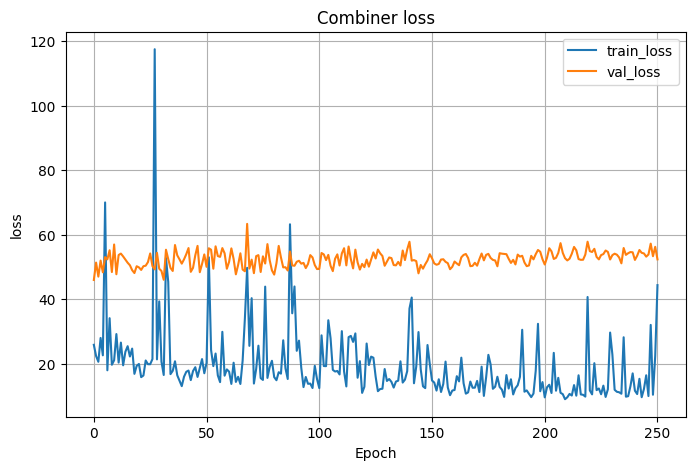

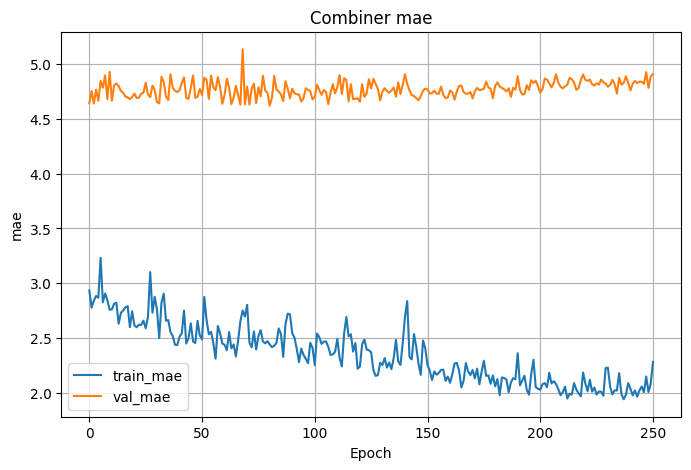

In [ ]:
plot_history(history_combiner, title_prefix="Combiner")


Saving final combiner model and running summary

In [ ]:
combiner_model.load_weights(str(combiner_best_path))

final_combiner_path = MODEL9_DIR / "final_combiner_model.keras"
combiner_model.save(final_combiner_path)

summary = {
    "model3_dir": str(MODEL3_DIR),
    "model9_dir": str(MODEL9_DIR),
    "side_backbone": SIDE_BACKBONE_PRESET,
    "rgb_img_height": RGB_IMG_HEIGHT,
    "rgb_img_width": RGB_IMG_WIDTH,
    "side_img_height": SIDE_IMG_HEIGHT,
    "side_img_width": SIDE_IMG_WIDTH,
    "batch_size": BATCH_SIZE,
    "mass_stage1_epochs": MASS_STAGE1_EPOCHS,
    "mass_stage2_epochs": MASS_STAGE2_EPOCHS,
    "combiner_epochs": COMBINER_EPOCHS,
    "mass_stage1_test_loss": float(mass_stage1_test_results.get("loss")),
    "mass_stage1_test_mae": float(mass_stage1_test_results.get("mae")),
    "mass_stage2_test_loss": float(mass_stage2_test_results.get("loss")),
    "mass_stage2_test_mae": float(mass_stage2_test_results.get("mae")),
    "combiner_test_loss": float(combiner_test_results.get("loss")),
    "combiner_test_mae": float(combiner_test_results.get("mae")),
    "combiner_test_mse": float(combiner_test_results.get("mse")),
    "combiner_test_pmae": float(combiner_test_pmae),
}

summary_path = MODEL9_DIR / "run_summary_modular.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved final combiner model to:", final_combiner_path)
print("Saved summary to:", summary_path)


Saved final combiner model to: /content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/final_combiner_model.keras
Saved summary to: /content/drive/MyDrive/Speciale/Models/Model_9_V2_DINOv2_RGB_plus_DINOv3_mass_estimation_plus_combiner/run_summary_modular.json
